In [6]:
import sys
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import wordfreq
from collections import Counter
%matplotlib inline
plt.style.use('ggplot')
sys.path.append(os.getcwd())

In [7]:
def lang_confidence_score(word_counts, language_top_words):
    top_words_set = set(language_top_words)
    match_count = 0
    total_words_in_text = sum(word_counts.values())
   
    if total_words_in_text == 0:
        return 0.0

    for word, count in word_counts.items():
        if word.lower() in top_words_set:
            match_count += count
            
    return match_count / total_words_in_text

In [12]:
def load_json_counts(filename):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
            return Counter(data)
    except FileNotFoundError:
        print(f"Brak pliku {filename}.")
        return Counter()

def load_text_as_counts(filename):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text = f.read()
            words = re.findall(r'[a-zA-ZżźćńółęąśŻŹĆŃÓŁĘĄŚäöüÄÖÜß]+', text.lower())
            return Counter(words)
    except FileNotFoundError:
        print(f"Brak pliku {filename}.")
        return Counter()

wiki_standard = load_json_counts('standard_wiki_words.json') 
wiki_niche = load_json_counts('niche_wiki_words.json')

print(f"Długi artykuł wiki (ilość słów): {sum(wiki_standard.values())}")
print(f"Artykuł wiki z niskim wynikiem (ilość słów): {sum(wiki_niche.values())}")

ext_en = load_text_as_counts('external_en.txt')
ext_pl = load_text_as_counts('external_pl.txt')
ext_de = load_text_as_counts('external_de.txt')

Długi artykuł wiki (ilość słów): 5802
Artykuł wiki z niskim wynikiem (ilość słów): 2879


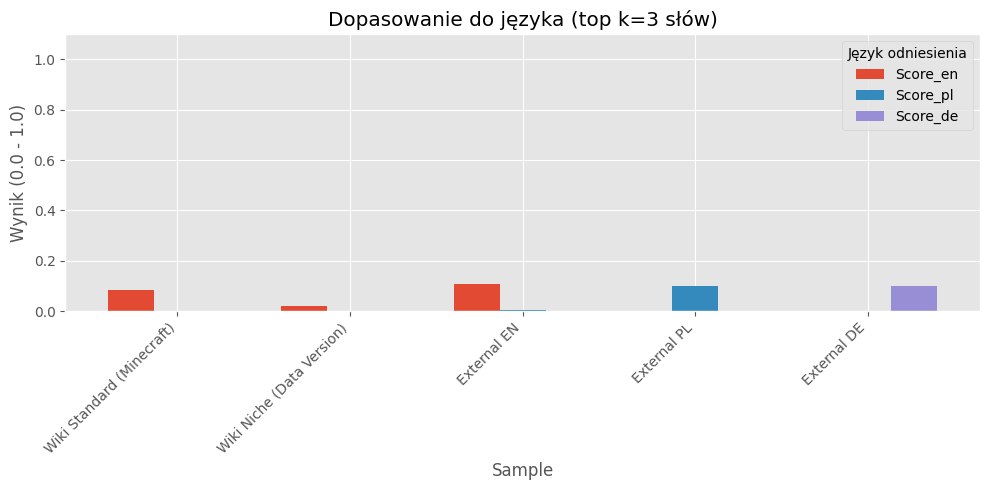

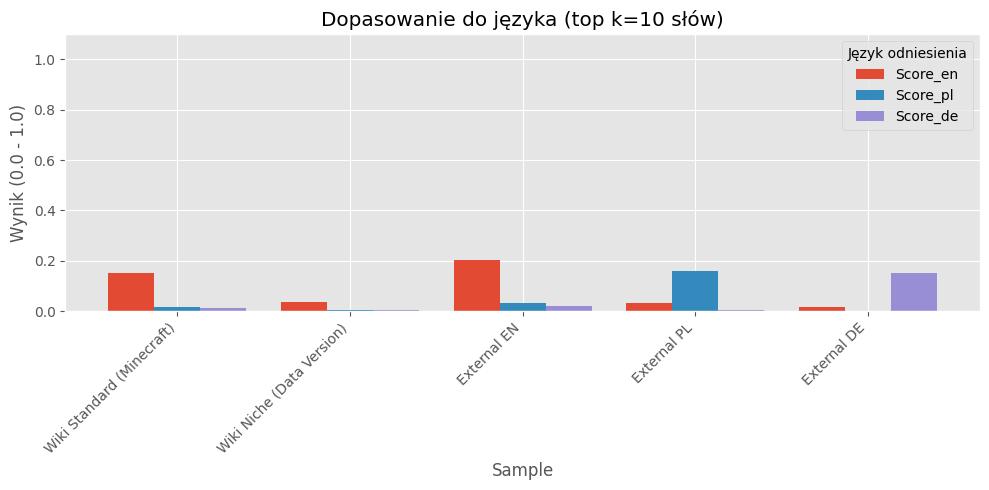

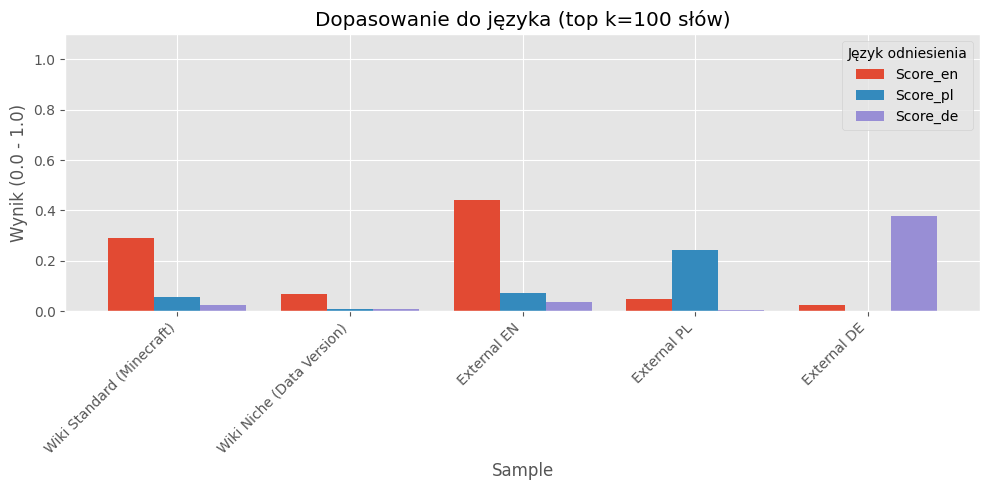

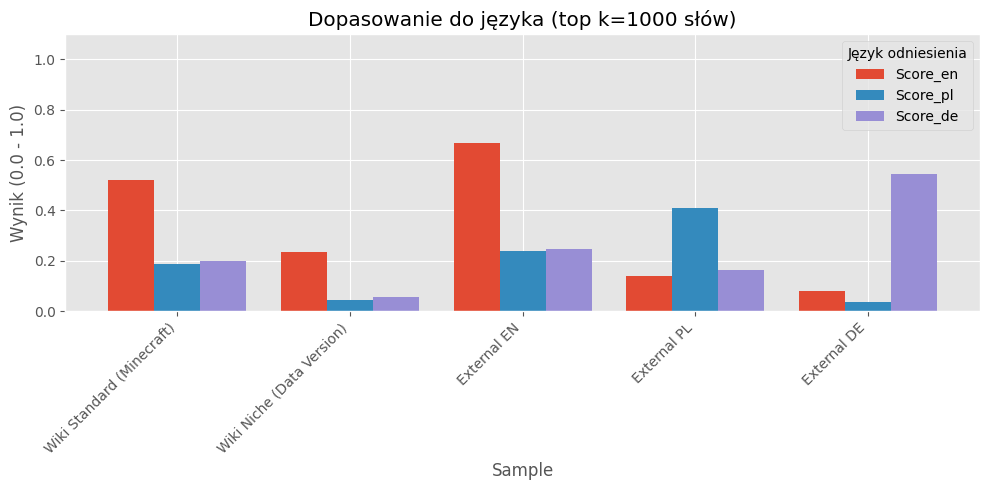

In [14]:
k_values = [3, 10, 100, 1000] 
languages = ['en', 'pl', 'de']

test_samples = {
    'Wiki Standard (Minecraft)': wiki_standard,
    'Wiki Niche (Data Version)': wiki_niche,
    'External EN': ext_en,
    'External PL': ext_pl,
    'External DE': ext_de
}

results = []

for k in k_values:
    top_words_map = {
        lang: wordfreq.top_n_list(lang, k) 
        for lang in languages
    }
    
    for sample_name, word_counts in test_samples.items():
        row = {'k': k, 'Sample': sample_name}
        
        for lang in languages:
            score = lang_confidence_score(word_counts, top_words_map[lang])
            row[f'Score_{lang}'] = score
            
        results.append(row)

df_results = pd.DataFrame(results)

for k in k_values:
    subset = df_results[df_results['k'] == k].set_index('Sample')
    score_cols = [c for c in subset.columns if c.startswith('Score_')]
    ax = subset[score_cols].plot(kind='bar', figsize=(10, 5), width=0.8)
    
    plt.title(f'Dopasowanie do języka (top k={k} słów)')
    plt.ylabel('Wynik (0.0 - 1.0)')
    plt.ylim(0, 1.1)
    plt.legend(title='Język odniesienia')
    plt.xticks(rotation=45, ha='right') 
    plt.tight_layout()
    plt.show()

# Wnioski z analizy

### 1. Czy dobór języków miał duże znaczenie?
Tak, miał duże znaczenie, ponieważ wybrane języki są leksykalnie różne w obrębie 1000 najczęściej używanych słów, dzięki czemu liczba fałszywych dopasowań (szczególnie dla k≤100) jest stosunkowo niewielka.

### 2. Czy po wartościach language_words_with_frequency dla danych i najczęstszych słowach z języka danych widać, że w wybranym języku słowa często są odmieniane?
Zdecydowanie tak. Widać to na przykładzie tekstu polskiego (`External PL`). Mimo że tekst jest po polsku, jego dopasowanie do wzorca `Score_pl` jest zauważalnie niższe niż dopasowanie tekstu angielskiego do angielskiego.

### 3. Czy trudno było znaleźć artykuł Wiki z niskim wynikiem? Czy to specyfika tego wiki?
Tak, było to trudne. Początkowo testowałem krótkie artykuły o technicznych aspetkach gry (np. "Air"), ale okazywało się, że mimo technicznego charakteru, zawierają one poprawne gramatycznie zdania pełne słów takich jak "is", "the", "are".
Aby uzyskać niski wynik, musiałem znaleźć artykuł **"Data version"**, który jest listą techniczną. Składa się on głównie z numerów wersji i identyfikatorów. Ponieważ słowa typu "Java", "Snapshot", czy "Edition" nie występują na liście 1000 najpopularniejszych słów języka angielskiego, algorytm poprawnie ocenił, że ten tekst w małym stopniu przypomina naturalny język angielski.
Raczej nie jest to specyfika tego konkretnego wiki, ponieważ zazwyczaj artykuły opisują daną frazę używając języka, w którym jest napisane wiki.